In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

# Load dataset
secom = fetch_ucirepo(id=179)

# Use original data since features and targets are None
df_original = secom.data.original
X = df_original.drop('class', axis=1)
y = pd.DataFrame({'Pass_Fail': df_original['class']})

# Reset index to align both
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

# Combine
df = pd.concat([X, y], axis=1)

print("Dataset shape:", df.shape)
print("\nPass/Fail distribution:")
print(df['Pass_Fail'].value_counts())

df.head(3)

Dataset shape: (1567, 592)

Pass/Fail distribution:
Pass_Fail
-1    1463
 1     104
Name: count, dtype: int64


,timestamp,Attribute 1,Attribute 2,Attribute 3,Attribute 4,Attribute 5,Attribute 6,Attribute 7,Attribute 8,Attribute 9,...,Attribute 582,Attribute 583,Attribute 584,Attribute 585,Attribute 586,Attribute 587,Attribute 588,Attribute 589,Attribute 590,Pass_Fail
0,19/07/2008 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,19/07/2008 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,19/07/2008 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1


In [24]:
print("=== MISSING VALUE ANALYSIS ===")

missing=df.isnull().sum()
missing_pct=(missing/len(df))*100

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
}).sort_values('Missing %', ascending=False)

print(f"Total features: {df.shape[1]}")
print(f"Features with missing data: {(missing > 0).sum()}")
print(f"\nTop 10 features with most missing data:")
print(missing_report[missing_report['Missing Count'] > 0].head(10))

# Fill missing values with column mean (standard yield engineering practice)
df_clean = df.fillna(df.mean(numeric_only=True))
print(f"\nAfter cleaning - any missing values left: {df_clean.isnull().sum().sum()}")

=== MISSING VALUE ANALYSIS ===
Total features: 592
Features with missing data: 538

Top 10 features with most missing data:
               Missing Count  Missing %
Attribute 294           1429      91.19
Attribute 293           1429      91.19
Attribute 158           1429      91.19
Attribute 159           1429      91.19
Attribute 493           1341      85.58
Attribute 221           1341      85.58
Attribute 86            1341      85.58
Attribute 359           1341      85.58
Attribute 519           1018      64.96
Attribute 383           1018      64.96

After cleaning - any missing values left: 0


       YIELD SUMMARY REPORT
  Total wafers tested  : 1567
  Passed               : 1463
  Failed               : 104
  Yield (%)            : 93.36%
  Defect rate (%)      : 6.64%


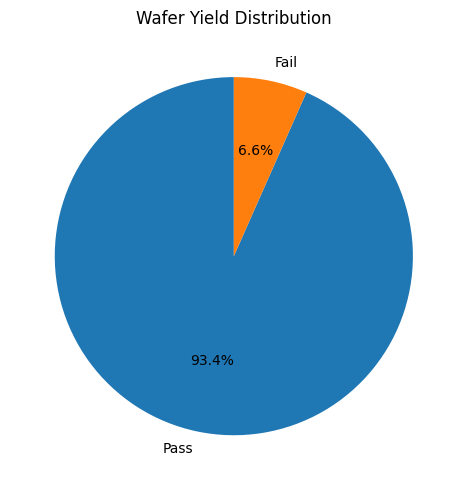

Chart saved as yield_distribution.png


In [25]:
total_wafers = len(df_clean)

# Ensure correct datatype
df_clean['Pass_Fail'] = pd.to_numeric(df_clean['Pass_Fail'], errors='coerce')

# Drop NaN target rows
df_clean = df_clean.dropna(subset=['Pass_Fail'])

fail_wafers  = (df_clean['Pass_Fail'] == 1).sum()
pass_wafers  = (df_clean['Pass_Fail'] == -1).sum()

yield_pct = (pass_wafers / total_wafers) * 100 if total_wafers > 0 else 0

print("=" * 40)
print("       YIELD SUMMARY REPORT")
print("=" * 40)
print(f"  Total wafers tested  : {total_wafers}")
print(f"  Passed               : {pass_wafers}")
print(f"  Failed               : {fail_wafers}")
print(f"  Yield (%)            : {yield_pct:.2f}%")
print(f"  Defect rate (%)      : {100 - yield_pct:.2f}%")
print("=" * 40)

# Plot yield pie chart
if pass_wafers == 0 and fail_wafers == 0:
    print("No valid data to plot")
else:
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.pie([pass_wafers, fail_wafers],
           labels=['Pass', 'Fail'],
           autopct='%1.1f%%',
           startangle=90)
    ax.set_title('Wafer Yield Distribution')
    plt.tight_layout()
    plt.savefig('yield_distribution.png', dpi=150)
    plt.show()

    print("Chart saved as yield_distribution.png")

In [21]:
# Debug: Check y
print("y shape:", y.shape)
print("y dtypes:", y.dtypes)
print("y head:", y.head())

print("\nX shape:", X.shape)
print("X columns (first 5):", list(X.columns)[:5])

print("\nAfter concat, df shape:", df.shape)
print("Pass_Fail column type:", df['Pass_Fail'].dtype)
print("Pass_Fail unique values:", df['Pass_Fail'].unique())
print("df['Pass_Fail'].head(10):", df['Pass_Fail'].head(10).values)

y shape: (0, 1)
y dtypes: Pass_Fail    object
dtype: object
y head: Empty DataFrame
Columns: [Pass_Fail]
Index: []

X shape: (1567, 591)
X columns (first 5): ['timestamp', 'Attribute 1', 'Attribute 2', 'Attribute 3', 'Attribute 4']

After concat, df shape: (1567, 592)
Pass_Fail column type: object
Pass_Fail unique values: [nan]
df['Pass_Fail'].head(10): [nan nan nan nan nan nan nan nan nan nan]


Top 10 sensor signals showing biggest Pass vs Fail difference:
Attribute 162    331.929795
Attribute 160    307.236177
Attribute 22     271.688294
Attribute 25     213.156316
Attribute 161    206.908517
Attribute 295    156.539576
Attribute 163    152.670316
Attribute 297    125.119971
Attribute 296    104.497182
Attribute 23      87.025584


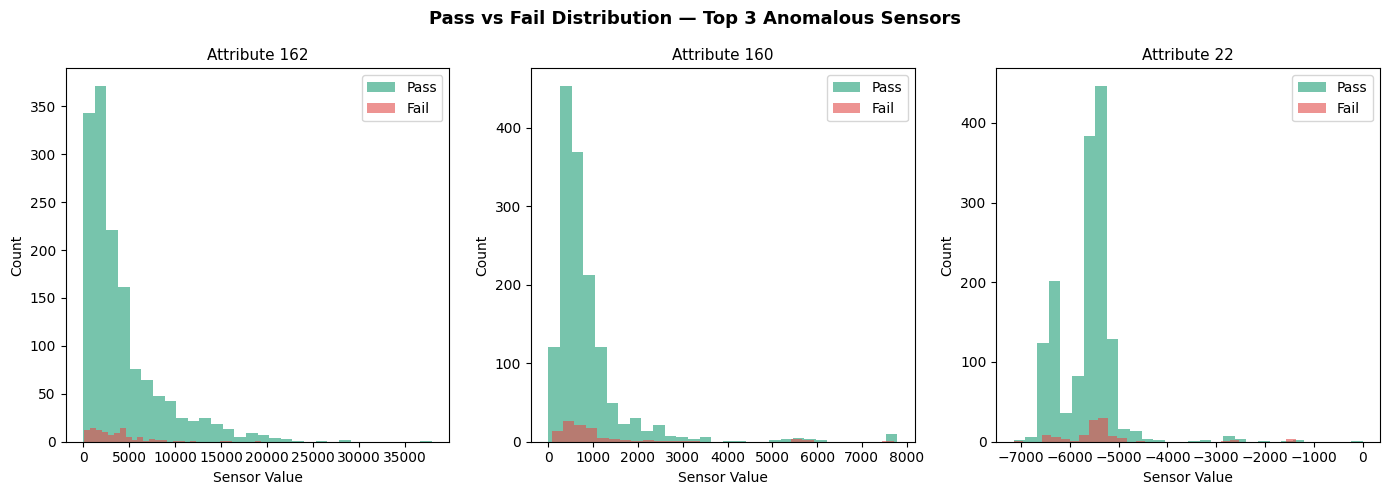

In [31]:
sensor_cols = df_clean.select_dtypes(include=[np.number]).columns[:-1]  # all numeric sensor columns

# Calculate mean values for pass and fail groups
pass_means = df_clean[df_clean['Pass_Fail']==-1][sensor_cols].mean()
fail_means = df_clean[df_clean['Pass_Fail']==1][sensor_cols].mean()

# Find sensors where fail mean differs most from pass mean (anomaly signals)
diff = abs(fail_means - pass_means)
top_sensors = diff.sort_values(ascending=False).head(10)

print("Top 10 sensor signals showing biggest Pass vs Fail difference:")
print(top_sensors.to_string())

# Plot: compare pass vs fail for top 3 sensors
top3 = top_sensors.index[:3].tolist()

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for i, sensor in enumerate(top3):
    pass_vals = df_clean[df_clean['Pass_Fail']==-1][sensor].dropna()
    fail_vals = df_clean[df_clean['Pass_Fail']==1][sensor].dropna()
    axes[i].hist(pass_vals, bins=30, alpha=0.6, color='#1D9E75', label='Pass')
    axes[i].hist(fail_vals, bins=30, alpha=0.6, color='#E24B4A', label='Fail')
    axes[i].set_title(f'{sensor}', fontsize=11)
    axes[i].set_xlabel('Sensor Value')
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.suptitle('Pass vs Fail Distribution — Top 3 Anomalous Sensors',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('parametric_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

  STATISTICAL REPORT — Sensor: Attribute 162
  Sample size        : 1567
  Mean               : 4066.8505
  Std deviation      : 4236.5371
  Min                : 0.0000
  Max                : 37943.0000
  Outliers (|z|>3)   : 31
  Outlier rate       : 1.98%


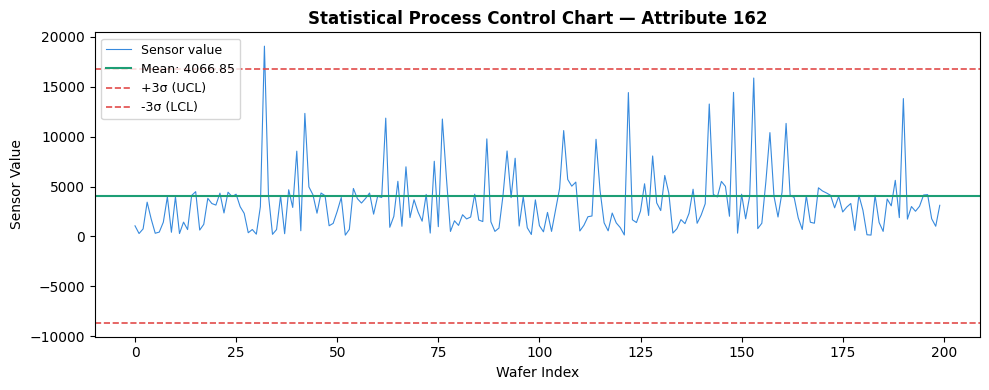

In [33]:
from scipy import stats

# Pick one important sensor for deep statistical analysis
sensor = top3[0]
values = df_clean[sensor].dropna()

mean_val = values.mean()
std_val  = values.std()
z_scores = np.abs(stats.zscore(values))
outliers = (z_scores > 3).sum()

print("=" * 45)
print(f"  STATISTICAL REPORT — Sensor: {sensor}")
print("=" * 45)
print(f"  Sample size        : {len(values)}")
print(f"  Mean               : {mean_val:.4f}")
print(f"  Std deviation      : {std_val:.4f}")
print(f"  Min                : {values.min():.4f}")
print(f"  Max                : {values.max():.4f}")
print(f"  Outliers (|z|>3)   : {outliers}")
print(f"  Outlier rate       : {(outliers/len(values)*100):.2f}%")
print("=" * 45)

# Control chart (simple SPC-style plot)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(values.values[:200], color='#378ADD', linewidth=0.8, label='Sensor value')
ax.axhline(mean_val,         color='#1D9E75', linewidth=1.5, linestyle='-',  label=f'Mean: {mean_val:.2f}')
ax.axhline(mean_val + 3*std_val, color='#E24B4A', linewidth=1.2, linestyle='--', label='+3σ (UCL)')
ax.axhline(mean_val - 3*std_val, color='#E24B4A', linewidth=1.2, linestyle='--', label='-3σ (LCL)')
ax.set_title(f'Statistical Process Control Chart — {sensor}', fontweight='bold')
ax.set_xlabel('Wafer Index')
ax.set_ylabel('Sensor Value')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('spc_chart.png', dpi=150, bbox_inches='tight')
plt.show()

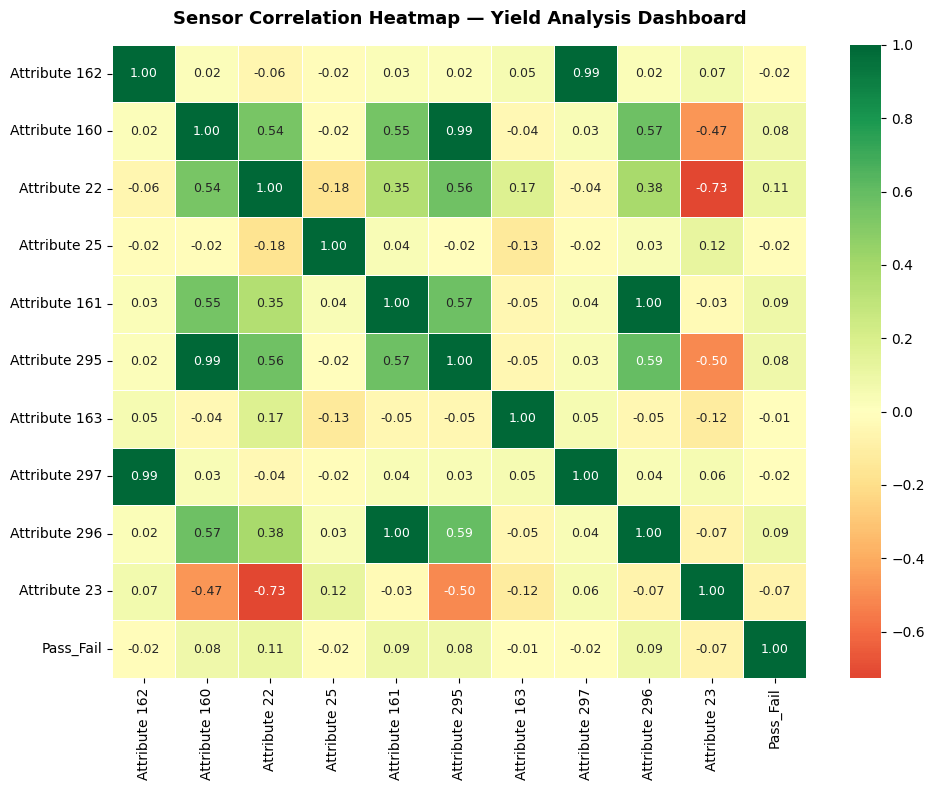

All 4 charts saved.


In [35]:
top10 = top_sensors.index[:10].tolist() + ['Pass_Fail']
corr_df = df_clean[top10].copy()

# Compute correlation matrix
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True, fmt='.2f',
            cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Sensor Correlation Heatmap — Yield Analysis Dashboard',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("All 4 charts saved.")